# Mini Project IA-340

### Research Question: 
#### "Are younger or older age groups driving recent increases in overdose deaths?"

## Step 1: Load data from AWS bucket

In [11]:
import boto3
import pandas as pd
from io import StringIO

s3 = boto3.client('s3')

bucket_name = 'ia340-steinfadt'
file_key = 'Drug_overdose_death_rates__by_drug_type__sex__age__race__and_Hispanic_origin__United_States.csv'

csv_obj = s3.get_object(Bucket=bucket_name, Key=file_key)
body = csv_obj['Body'].read().decode('utf-8')

df = pd.read_csv(StringIO(body))

df.head()

,INDICATOR,PANEL,PANEL_NUM,UNIT,UNIT_NUM,STUB_NAME,STUB_NAME_NUM,STUB_LABEL,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE,AGE_NUM,ESTIMATE,FLAG
0,Drug overdose death rates,All drug overdose deaths,0,"Deaths per 100,000 resident population, age-ad...",1,Total,0,All persons,0.1,1999,1,All ages,1.1,6.1,NaN
1,Drug overdose death rates,All drug overdose deaths,0,"Deaths per 100,000 resident population, age-ad...",1,Total,0,All persons,0.1,2000,2,All ages,1.1,6.2,NaN
2,Drug overdose death rates,All drug overdose deaths,0,"Deaths per 100,000 resident population, age-ad...",1,Total,0,All persons,0.1,2001,3,All ages,1.1,6.8,NaN
3,Drug overdose death rates,All drug overdose deaths,0,"Deaths per 100,000 resident population, age-ad...",1,Total,0,All persons,0.1,2002,4,All ages,1.1,8.2,NaN
4,Drug overdose death rates,All drug overdose deaths,0,"Deaths per 100,000 resident population, age-ad...",1,Total,0,All persons,0.1,2003,5,All ages,1.1,8.9,NaN


### Dataset Documentation
- Source: https://catalog.data.gov/dataset/drug-overdose-death-rates-by-drug-type-sex-age-race-and-hispanic-origin-united-states-3f72f
- This data shows records of drug overdoes in the US based on drug type and selected population characteristics such as sex, age, and race
- The time period covered is 1999–2018, based on data from the CDC
- I find this topic interesting because I am currently in a WMD class that is discussing drug overdose, and it relates to my research question by showing how prevalent drug overdoses have been over time and what factors are driving the changes and increases

## Step 2: Clean

In [12]:
df.info()
df.describe(include='all')
df_clean.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6228 entries, 0 to 6227
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDICATOR       6228 non-null   object 
 1   PANEL           6228 non-null   object 
 2   PANEL_NUM       6228 non-null   int64  
 3   UNIT            6228 non-null   object 
 4   UNIT_NUM        6228 non-null   int64  
 5   STUB_NAME       6228 non-null   object 
 6   STUB_NAME_NUM   6228 non-null   int64  
 7   STUB_LABEL      6228 non-null   object 
 8   STUB_LABEL_NUM  6228 non-null   float64
 9   YEAR            6228 non-null   int64  
 10  YEAR_NUM        6228 non-null   int64  
 11  AGE             6228 non-null   object 
 12  AGE_NUM         6228 non-null   float64
 13  ESTIMATE        5117 non-null   float64
 14  FLAG            1111 non-null   object 
dtypes: float64(3), int64(5), object(7)
memory usage: 730.0+ KB


0

### Missing Values & Duplicates Check 
There is a total of 6,228 values in this data set but 'ESTIMATE' seems to be missing 1,111 values and 'FLAG' has 5,117 missing values! It also return 0 on the last line of code indicating there are no duplicates in the data set
### Removing FLAGGED Data Points 
The source notes that (*) are considered unreliable and rates based on fewer than 20 deaths are not shown

In [13]:
df_clean = df[df['FLAG'].isnull()]
len(df) - len(df_clean)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5117 entries, 0 to 6225
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDICATOR       5117 non-null   object 
 1   PANEL           5117 non-null   object 
 2   PANEL_NUM       5117 non-null   int64  
 3   UNIT            5117 non-null   object 
 4   UNIT_NUM        5117 non-null   int64  
 5   STUB_NAME       5117 non-null   object 
 6   STUB_NAME_NUM   5117 non-null   int64  
 7   STUB_LABEL      5117 non-null   object 
 8   STUB_LABEL_NUM  5117 non-null   float64
 9   YEAR            5117 non-null   int64  
 10  YEAR_NUM        5117 non-null   int64  
 11  AGE             5117 non-null   object 
 12  AGE_NUM         5117 non-null   float64
 13  ESTIMATE        5117 non-null   float64
 14  FLAG            0 non-null      object 
dtypes: float64(3), int64(5), object(7)
memory usage: 639.6+ KB


this output means we got rid of 1,111 flagged values and now there are no non-null values and the data has gotten rid of unreliable data

In [14]:
df_clean['AGE'].unique()

array(['All ages', 'Under 15 years', '15-24 years', '25-34 years',
       '35-44 years', '45-54 years', '55-64 years', '65-74 years',
       '75-84 years', '85 years and over'], dtype=object)

This is displaying the age catergories and we are going to remove "all ages" since we want to compare seperate age categories 

In [15]:
df_age = df_clean[df_clean['AGE'] != 'All ages']

In [16]:
df_age_trend = (
    df_age.groupby(['YEAR', 'AGE'])['ESTIMATE']
    .mean()
    .reset_index()
)

This gives you a summarized table of average overdose death rates by age and year

## Step 3: Process

In [17]:
year_min = df_age_trend['YEAR'].min()
year_max = df_age_trend['YEAR'].max()

age_change = (
    df_age_trend[df_age_trend['YEAR'].isin([year_min, year_max])]
    .pivot(index='AGE', columns='YEAR', values='ESTIMATE')
    .reset_index()
)

#Adding the absolute and percent change columns
age_change['absolute_increase'] = age_change[year_max] - age_change[year_min]
age_change['percent_change'] = ((age_change[year_max] - age_change[year_min]) / age_change[year_min]) * 100

age_change = age_change.sort_values('percent_change', ascending=False)
age_change

YEAR,AGE,1999,2018,absolute_increase,percent_change
4,55-64 years,1.393333,11.422222,10.028889,719.776715
1,25-34 years,2.533333,16.783333,14.250000,562.500000
0,15-24 years,1.106250,4.961111,3.854861,348.462021
3,45-54 years,3.488889,14.833333,11.344444,325.159236
5,65-74 years,0.980000,3.922222,2.942222,300.226757
2,35-44 years,4.450000,17.183333,12.733333,286.142322
6,75-84 years,1.400000,1.733333,0.333333,23.809524
8,Under 15 years,0.100000,0.112500,0.012500,12.500000
7,85 years and over,3.900000,1.962500,-1.937500,-49.679487


### How do these new columns support my research question?
Adding the "absolute_increase" column shows directly the largest numerical increase and showing who’s adding the most to total deaths. The "percent_change" is showing relative growth from the starting year which gives evedince to which age groups’ rates are growing fastest, even if they started from smaller numbers. These both great variables to help compare the ages group to determine if it is younger or older populations driving the drug overdose rise.

## Step 4: Query

In [20]:
df_2018_age = df_clean[
    (df_clean['YEAR'] == 2018) &
    (df_clean['AGE'] != 'All ages')
]

df_2018_age = df_2018_age[['YEAR', 'AGE', 'ESTIMATE']].dropna()
age_order = [
    'Under 15 years',
    '15-24 years',
    '25-34 years',
    '35-44 years',
    '45-54 years',
    '55-64 years',
    '65-74 years',
    '75-84 years',
    '85 years and over'
]

df_2018_age = df_2018_age.copy()
df_2018_age['AGE'] = pd.Categorical(df_2018_age['AGE'], categories=age_order, ordered=True)
df_2018_age = df_2018_age.sort_values('AGE')

pd.set_option('display.max_rows', None)
df_2018_age[['YEAR', 'AGE', 'ESTIMATE']]

,YEAR,AGE,ESTIMATE
5944,2018,Under 15 years,0.2
5964,2018,Under 15 years,0.2
6006,2018,Under 15 years,0.1
6015,2018,Under 15 years,0.1
5995,2018,Under 15 years,0.1
5955,2018,Under 15 years,0.2
6046,2018,Under 15 years,0.0
6148,2018,Under 15 years,0.0
6058,2018,15-24 years,2.2
6047,2018,15-24 years,1.6


### Why is this Filter Meaningful?
What I did above
- filtered your data to focus on the most recent year (2018) because my research question focuses 
- removed “All ages” summaries to focus on actual age groups
- purposely sorted the results from youngest to oldest to make age patterns clear and not scattered

The fliter shows the current situation more clearly such as which age groups have the highest overdose death rates and lets me determined who is most impacted recently

## Step 5: Visualize data

Matplotlib is building the font cache; this may take a moment.


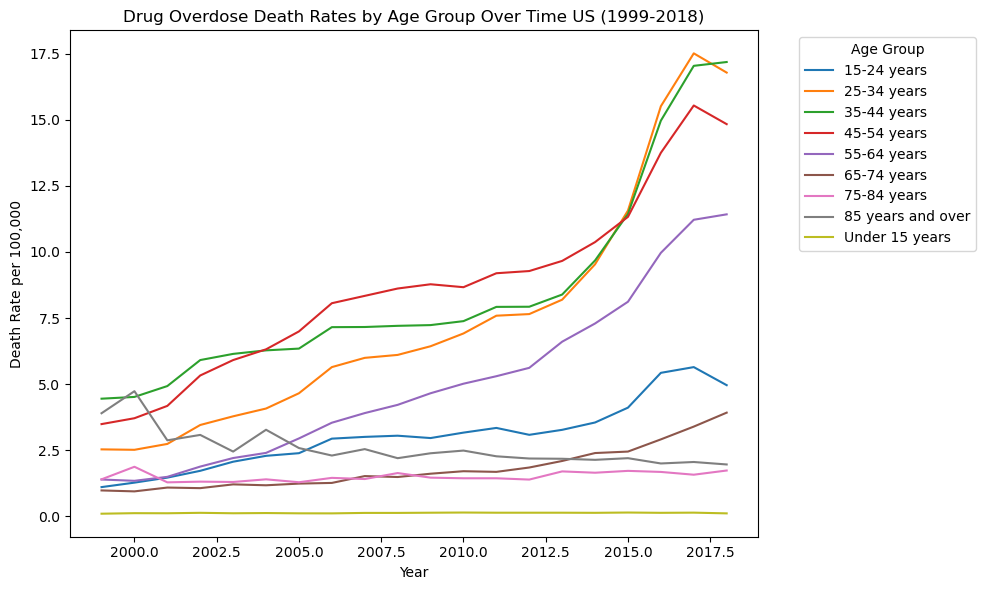

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(data=df_age_trend, x='YEAR', y='ESTIMATE', hue='AGE')
plt.title('Drug Overdose Death Rates by Age Group Over Time US (1999-2018)')
plt.xlabel('Year')
plt.ylabel('Death Rate per 100,000')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Each colored line represents an age group listed on the top right side. Although some lines are steeper than others, almost all of them show an increase in death rates, indicating that drug overdosing has worsened in recent years

In [22]:
year_min, year_max = df_age_trend['YEAR'].min(), df_age_trend['YEAR'].max()

change = (
    df_age_trend[df_age_trend['YEAR'].isin([year_min, year_max])]
    .pivot(index='AGE', columns='YEAR', values='ESTIMATE')
)
change['increase'] = change[year_max] - change[year_min]
change.sort_values('increase', ascending=False)

YEAR,1999,2018,increase
AGE,,,
25-34 years,2.533333,16.783333,14.250000
35-44 years,4.450000,17.183333,12.733333
45-54 years,3.488889,14.833333,11.344444
55-64 years,1.393333,11.422222,10.028889
15-24 years,1.106250,4.961111,3.854861
65-74 years,0.980000,3.922222,2.942222
75-84 years,1.400000,1.733333,0.333333
Under 15 years,0.100000,0.112500,0.012500
85 years and over,3.900000,1.962500,-1.937500


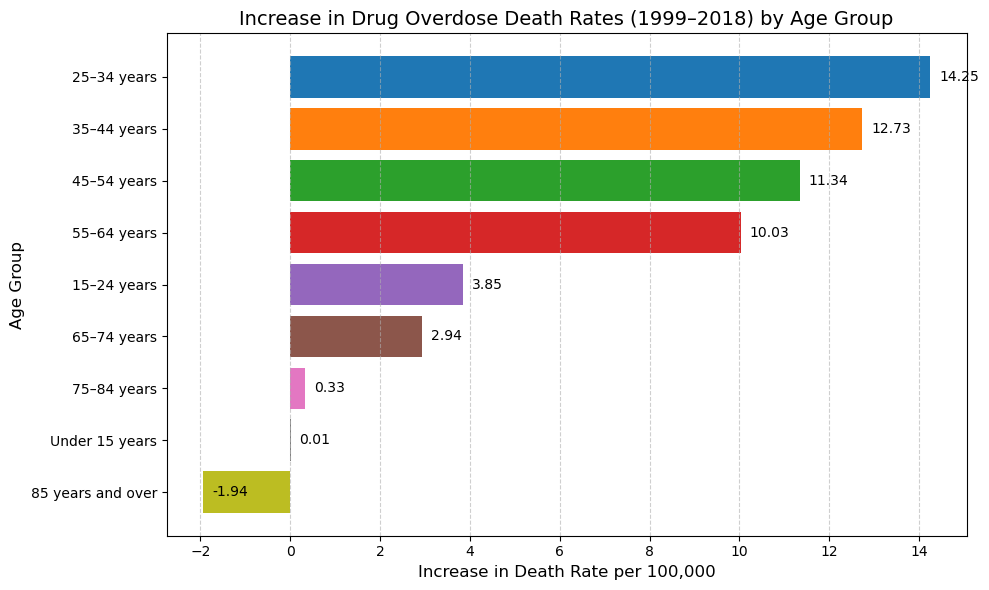

In [23]:
increase_df = pd.DataFrame({
    'AGE': ['25–34 years','35–44 years','45–54 years','55–64 years',
            '15–24 years','65–74 years','75–84 years','Under 15 years','85 years and over'],
    'Increase': [14.25,12.73,11.34,10.03,3.85,2.94,0.33,0.01,-1.94]
})

colors = plt.cm.tab10.colors  # tab10 gives 10 nice distinct colors

plt.figure(figsize=(10,6))
bars = plt.barh(increase_df['AGE'], increase_df['Increase'], color=colors[:len(increase_df)])

plt.title('Increase in Drug Overdose Death Rates (1999–2018) by Age Group', fontsize=14)
plt.xlabel('Increase in Death Rate per 100,000', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, (val, age) in enumerate(zip(increase_df['Increase'], increase_df['AGE'])):
    plt.text(val + 0.2, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

This bar chart makes it easier to quantify which age group is driving drug overdoses. It appears that young adults have the highest death rate percentage, with the peak at 14.25% among those aged 25–34 years. The only decrease in death rates is seen in the age group of 85 years or older.

## Findings from Charts
This charts quantify the changes and highlights the increases of each age group 

The strongest increases in my data
- 25–34 years (+14.25)
- 35–44 years (+12.73)
- 45–54 years (+11.34)

These age groups are the most responsible for the rise of overdose death rates since 1999

There was a moderate increase older adults 55–64 years (+10.03). This trend is still less steep than the middle-aged group